# Paper outputs (MLST)

Creates all values, tables and figures used in the manuscript under `iop_mlst/`. The notebook only reads results, data and models from the source directories and never writes back to them. All outputs are English and locale-neutral, so the dissertation exports stay untouched.

Outputs go to `iop_mlst/generated/` and are included in the preamble of `iopjournal.tex`.

## Paths

The repository root is found as the nearest parent directory containing `pyproject.toml`, so the notebook runs from any location. The simulator sources of the pyTEP fork are expected next to the repository (`../pytep/pytep/simulator`) unless `PYTEP_SIMULATOR_DIR` is set.

In [1]:
import os
from pathlib import Path

base_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
results_dir = base_dir / "results"
paper_dir = base_dir / "iop_mlst"
generated_dir = paper_dir / "generated"
simulator_dir = Path(os.environ.get("PYTEP_SIMULATOR_DIR",
                                    base_dir.parent / "pytep" / "pytep" / "simulator"))

generated_dir.mkdir(exist_ok=True)
base_dir, simulator_dir

(WindowsPath('c:/git/process_optimization_concept_drift'),
 WindowsPath('c:/git/pytep/pytep/simulator'))

## IDV(29) parameters

Two sources carry the parameters of the drift.

- The `#define`s in `temexd_mod.c` and `drift_function.c` fix segment duration, boundary shift, seed and the value range of $c(t)$. They are parsed from the C sources instead of being repeated here, since the simulator compiles exactly these values.
- `results/tep_generation.json` holds the drift coefficient $\kappa_m$ the stored run was generated with, together with the resulting peak calibration error.

In [2]:
import json
import re


def read_defines(path):
    pattern = re.compile(r"^#define\s+(\w+)\s+([-+0-9.eE]+)(?:ULL)?\b", re.MULTILINE)
    return {name: float(value) for name, value in pattern.findall(path.read_text(encoding="latin-1"))}


defines = {**read_defines(simulator_dir / "temexd_mod.c"),
           **read_defines(simulator_dir / "drift_function.c")}
generation = json.loads((results_dir / "tep_generation.json").read_text(encoding="utf-8"))
model_params = json.loads((results_dir / "tep_model_error.json").read_text(encoding="utf-8"))
drift_amplitude = generation["drift_amplitude"]

assert drift_amplitude["idv"] == 29
{key: defines[key] for key in ("DRIFT_PERIOD", "DRIFT_GAMMA", "DRIFT_SEED", "CD_MID", "CD_HALF")}

{'DRIFT_PERIOD': 1752.0,
 'DRIFT_GAMMA': 0.2,
 'DRIFT_SEED': 42.0,
 'CD_MID': 0.0,
 'CD_HALF': 0.5}

The bands follow `drift_function.c`: the start level is drawn from the upper half of the value range without its inner quarter, the target level from the lower half accordingly.

In [3]:
cd_mid, cd_half = defines["CD_MID"], defines["CD_HALF"]
upper_band = (cd_mid + cd_half / 4, cd_mid + cd_half)
lower_band = (cd_mid - cd_half, cd_mid - cd_half / 4)
upper_band, lower_band

((0.125, 0.5), (-0.5, -0.125))

## Export

Numbers are written as `\num{}`/`\SI{}{}` with a decimal point, so siunitx sets them according to the paper's locale. Macro names carry the prefix `idv`.

In [8]:
from src.utils.latex_export import MacroExport

HOURS_PER_DAY = 24

def num(value, nd=None):
    text = f"{value:g}" if nd is None else f"{value:.{nd}f}"
    return rf"\num{{{text}}}"


def quantity(value, unit, nd=None):
    text = f"{value:g}" if nd is None else f"{value:.{nd}f}"
    return rf"\SI{{{text}}}{{{unit}}}"


macros = (MacroExport("generated by paper_outputs.ipynb - do not edit")
          .comment("IDV(29): parameters from temexd_mod.c, drift_function.c and results/tep_generation.json")
          .integer("idvIndex", drift_amplitude["idv"])
          .raw("idvDriftCoefficient", num(drift_amplitude["amp"]))
          .raw("idvSegmentDuration", quantity(defines["DRIFT_PERIOD"] / HOURS_PER_DAY, r"\day"))
          .raw("idvShiftFraction", num(defines["DRIFT_GAMMA"]))
          .integer("idvSeed", defines["DRIFT_SEED"])
          .raw("idvUpperBandLow", num(upper_band[0]))
          .raw("idvUpperBandHigh", num(upper_band[1]))
          .raw("idvLowerBandLow", num(lower_band[0]))
          .raw("idvLowerBandHigh", num(lower_band[1]))
          .raw("idvPeakErrorPercent", quantity(drift_amplitude["peak_pct"], r"\percent", 1))
          .raw("idvPeakErrorKelvin", quantity(drift_amplitude["peak_k"], r"\kelvin", 1))
          .comment("Data stream generation: results/tep_generation.json")
          .raw("genSetpointSpan", quantity(100 * generation["magnitude_range"][1], r"\percent", 0))
          .integer("genPointsPerMode", generation["n_points_per_mode"])
          .integer("genCandidates", generation["n_candidates"])
          .integer("genFeasible", generation["n_feasible"])
          .integer("genRunPoints", generation["run_points"])
          .raw("genRunYears", num(generation["run_years"], 0))
          .raw("genRampDuration", quantity(generation["block_hours"]["ramp"]/24, r"\day", 0))
          .raw("genHoldDuration", quantity((generation["block_hours"]["soak"]
                                           - generation["block_hours"]["ramp"])/24, r"\day", 0))
          .raw("genBlockDuration", quantity((generation["block_hours"]["ramp"]
                                            + generation["block_hours"]["soak"])/24, r"\day", 0))
          .integer("modelCampaignPoints", model_params["n_campaign"])
          .integer("modelWindowSize", model_params["window_size"])
          .integer("modelLayers", model_params["n_layers"])
          .integer("modelNeurons", model_params["n_neurons"])
          .integer("modelEpochs", model_params["n_epochs"])
          .integer("modelBatch", model_params["batch_size"]))

output = generated_dir / "tep_values.tex"
output.write_text(macros.render(), encoding="utf-8")
print(macros.render())

% generated by paper_outputs.ipynb - do not edit

% IDV(29): parameters from temexd_mod.c, drift_function.c and results/tep_generation.json
\newcommand{\idvIndex}{29}
\newcommand{\idvDriftCoefficient}{\num{0.3}}
\newcommand{\idvSegmentDuration}{\SI{73}{\day}}
\newcommand{\idvShiftFraction}{\num{0.2}}
\newcommand{\idvSeed}{42}
\newcommand{\idvUpperBandLow}{\num{0.125}}
\newcommand{\idvUpperBandHigh}{\num{0.5}}
\newcommand{\idvLowerBandLow}{\num{-0.5}}
\newcommand{\idvLowerBandHigh}{\num{-0.125}}
\newcommand{\idvPeakErrorPercent}{\SI{14.7}{\percent}}
\newcommand{\idvPeakErrorKelvin}{\SI{9.2}{\kelvin}}

% Data stream generation: results/tep_generation.json
\newcommand{\genSetpointSpan}{\SI{15}{\percent}}
\newcommand{\genPointsPerMode}{50}
\newcommand{\genCandidates}{300}
\newcommand{\genFeasible}{136}
\newcommand{\genRunPoints}{122}
\newcommand{\genRunYears}{\num{2}}
\newcommand{\genRampDuration}{\SI{2}{\day}}
\newcommand{\genHoldDuration}{\SI{2}{\day}}
\newcommand{\genBlockDuration}{\SI{

## Figure: drift signal

The drift signal is taken from the recorded fault run instead of being evaluated from the C source, so the figure shows exactly the drift contained in the dataset. `driftf` is the ratio of the recorded stripper temperature in the fault run to that in the nominal run over the same sequence of operating points (column added in `tep_generation`), hence $c(t) = (\texttt{driftf} - 1)/\kappa_m$.

The run id comes from the provenance of `results/tep_generation.json`, so figure and table refer to the same run. The data were written in `.venv_tep` and are only read here (`rename=False`).

Segment boundaries are the upward jumps of `drift_segment`. The jump at activation, right at the start of the run, is excluded via `ACTIVATION_TOLERANCE_H`.

In [5]:
import numpy as np
import pandas as pd
from src.utils import run_registry as rr

data_store = rr.tep_data_store(base_dir / "data" / "tep")
error_data = data_store.load("data_error", run_id=generation["_provenance"]["id"], rename=False)

ACTIVATION_TOLERANCE_H = 1.0

kappa = drift_amplitude["amp"]
drift = pd.DataFrame({"time": error_data["time"].to_numpy(dtype=float),
                      "c": (error_data["driftf"].to_numpy(dtype=float) - 1.0) / kappa,
                      "segment": error_data["drift_segment"].to_numpy(dtype=int)})
assert drift["time"].is_monotonic_increasing
jumps = drift.loc[drift["segment"].diff() > 0, "time"].to_numpy()
boundaries = jumps[jumps > drift["time"].iloc[0] + ACTIVATION_TOLERANCE_H]
print(f"{len(boundaries) + 1} segments, boundaries at", boundaries.round(0))


11 segments, boundaries at [ 1694.  3653.  5390.  7018.  8623. 10581. 12216. 14003. 15614. 17414.]


Two panels at text width (153 mm, `iopjournal.cls`). The upper panel shows the whole run, the lower one the first `ZOOM_SEGMENTS` segments, whose range is shaded above. The bands of the start and target levels are shaded in both. Text is set by the document via PGF (`pgf.rcfonts = False`), so the figure uses the paper's font and needs `\usepackage{pgf}` in the preamble.

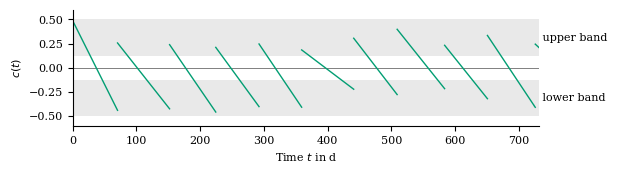

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

TEXTWIDTH_IN = 153 / 25.4
FONT_PT = 8
STRIDE = 10
HOURS_PER_DAY = 24

mpl.rcParams.update({
    "pgf.texsystem": "xelatex", "pgf.rcfonts": False,
    "font.family": "serif", "font.size": FONT_PT,
    "axes.labelsize": FONT_PT, "xtick.labelsize": FONT_PT, "ytick.labelsize": FONT_PT,
    "axes.spines.top": False, "axes.spines.right": False,
})

pieces = drift.iloc[::STRIDE].groupby("segment")[["time", "c"]]
gap = pd.DataFrame({"time": [np.nan], "c": [np.nan]})
piecewise = pd.concat([part for _, frame in pieces for part in (frame, gap)], ignore_index=True)

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 0.25 * TEXTWIDTH_IN))
for band in (upper_band, lower_band):
    ax.axhspan(*band, color=ts.C["box"], alpha=0.12, lw=0)
ax.axhline(0.0, color=ts.C["box"], lw=0.5)
ax.plot(piecewise["time"] / HOURS_PER_DAY, piecewise["c"], **ts.line("drift_signal", lw=1.0, alpha=1.0))
t_end = drift["time"].iloc[-1] / HOURS_PER_DAY
ax.text(t_end, np.mean(upper_band), " upper band", va="center", ha="left")
ax.text(t_end, np.mean(lower_band), " lower band", va="center", ha="left")
ax.set_xlim(0.0, t_end)
ax.set_ylim(-0.6, 0.6)
ax.set_xlabel("Time $t$ in d")
ax.set_ylabel("$c(t)$")

figures_dir = paper_dir / "figures"
figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / "drift_signal.pgf", bbox_inches="tight")
plt.show()

## Figure: excerpt of the data stream

Two panels over the same four operating points, chosen so that a segment boundary of the drift falls near the center of the window. The upper panel shows the block structure, with the setpoint of the production rate and two recorded variables normalized to their range over the whole run. The lower panel shows the stripper temperature of both runs in degrees Celsius together with $c(t)$ on a second ordinate.

The nominal run is read with the production id from the provenance of `results/tep_generation.json`, so both panels refer to the same run as the table and the drift figure. Point clouds are rasterized, the axes and text stay vectorial.

blocks [177, 73, 216, 167], boundary offset 0.06


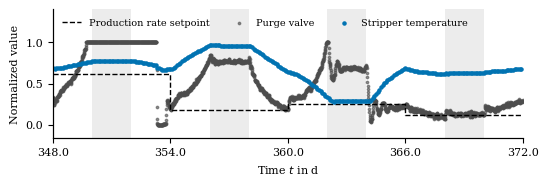

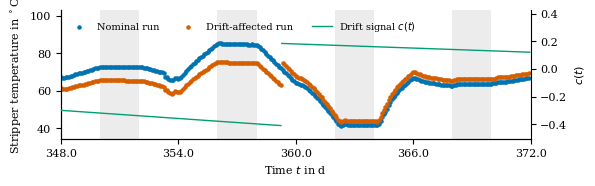

In [7]:
BLOCKS = 4
STRIDE_SENSOR = 40
STRIDE_CONTEXT = 5
STRIDE_DRIFT = 20
RASTER_DPI = 300
PANEL_HEIGHT = 0.30
HEAD_ROOM = 0.32
FOOT_ROOM = 0.10
LAYOUT = dict(left=0.11, right=0.89, bottom=0.26, top=0.97)
SENSOR_COLUMN = "Stripper Temp"
CONTEXT_COLUMN = "Purge valve"
SETPOINT_COLUMN = "ProductionSP"

ramp_h = generation["block_hours"]["ramp"]
soak_h = generation["block_hours"]["soak"]

production_data = data_store.load(
    "data_production", run_id=generation["_provenance"]["parents"]["production"], rename=False)

block_order = production_data["mode"].drop_duplicates().to_list()
block_times = production_data.groupby("mode", sort=False)["time"].agg(["min", "max"]).loc[block_order]

windows = []
for i in range(len(block_order) - BLOCKS + 1):
    t_start = float(block_times["min"].iloc[i])
    t_end = float(block_times["max"].iloc[i + BLOCKS - 1])
    inside = boundaries[(boundaries > t_start) & (boundaries < t_end)]
    if inside.size:
        center = 0.5 * (t_start + t_end)
        windows.append((float(np.min(np.abs(inside - center)) / (0.5 * (t_end - t_start))), i))
first_block = min(windows)[1]
window_blocks = block_order[first_block:first_block + BLOCKS]
print(f"blocks {window_blocks}, boundary offset {min(windows)[0]:.2f}")

nominal_window = production_data[production_data["mode"].isin(window_blocks)]
error_window = error_data[error_data["mode"].isin(window_blocks)]
block_starts = [float(block["time"].iloc[0])
                for _, block in nominal_window.groupby("mode", sort=False)]
t_lo, t_hi = block_starts[0], float(nominal_window["time"].iloc[-1])


def in_days(hours):
    return np.asarray(hours, dtype=float) / HOURS_PER_DAY


def unit_scale(values, reference):
    lo, hi = float(reference.min()), float(reference.max())
    return (values - lo) / (hi - lo)


def frame(ax):
    for _, block in nominal_window.groupby("mode", sort=False):
        t0 = float(block["time"].iloc[0])
        ax.axvspan(*in_days([t0 + ramp_h, min(t0 + soak_h, float(block["time"].iloc[-1]))]),
                   color=ts.C["box"], alpha=0.10, lw=0)
    ax.set_xlim(*in_days([t_lo, t_hi]))
    ax.set_xticks(in_days(block_starts + [t_hi]))
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.1f"))
    ax.set_xlabel("Time $t$ in d")


def pad(ax):
    lo, hi = ax.get_ylim()
    span = hi - lo
    ax.set_ylim(lo - FOOT_ROOM * span, hi + HEAD_ROOM * span)

def hold_level(block, column):
    t0 = float(block["time"].iloc[0])
    hold = block[(block["time"] >= t0 + ramp_h) & (block["time"] <= t0 + soak_h)]
    return float((hold if not hold.empty else block)[column].median())


sensor_nominal = nominal_window.iloc[::STRIDE_SENSOR]
sensor_error = error_window.iloc[::STRIDE_SENSOR]
context_nominal = nominal_window.iloc[::STRIDE_CONTEXT]

fig_point, ax_point = plt.subplots(figsize=(TEXTWIDTH_IN, PANEL_HEIGHT * TEXTWIDTH_IN))
frame(ax_point)

ax_mirror = ax_point.twinx()
ax_mirror.set_yticks([])
ax_mirror.set_ylabel("", color="none")

levels = [hold_level(block, SETPOINT_COLUMN)
          for _, block in nominal_window.groupby("mode", sort=False)]
ax_point.step(in_days(block_starts + [t_hi]),
              unit_scale(np.array(levels + levels[-1:]), production_data[SETPOINT_COLUMN]),
              where="post", label="Production rate setpoint", **ts.line("setpoint", lw=1.0))
ax_point.scatter(in_days(context_nominal["time"]),
                 unit_scale(context_nominal[CONTEXT_COLUMN], production_data[CONTEXT_COLUMN]),
                 color=ts.C["box"], alpha=0.6, s=3, marker="o", label="Purge valve",
                 rasterized=True)
ax_point.scatter(in_days(sensor_nominal["time"]),
                 unit_scale(sensor_nominal[SENSOR_COLUMN], production_data[SENSOR_COLUMN]),
                 label="Stripper temperature", rasterized=True, zorder=3,
                 **ts.scatter("drift_free", s=5))
ax_point.set_ylabel("Normalized value")
pad(ax_point)
ax_point.legend(loc="upper left", ncol=3, frameon=False, fontsize=FONT_PT - 1)
fig_point.subplots_adjust(**LAYOUT)
fig_point.savefig(figures_dir / "tep_stream_point.pgf", bbox_inches=None, dpi=RASTER_DPI)
plt.show()

fig_drift, ax_drift = plt.subplots(figsize=(TEXTWIDTH_IN, PANEL_HEIGHT * TEXTWIDTH_IN))
frame(ax_drift)
ax_drift.scatter(in_days(sensor_nominal["time"]), sensor_nominal[SENSOR_COLUMN],
                 label="Nominal run", rasterized=True, **ts.scatter("drift_free", s=5))
ax_drift.scatter(in_days(sensor_error["time"]), sensor_error[SENSOR_COLUMN],
                 label="Drift-affected run", rasterized=True, **ts.scatter("drift_afflicted", s=5))
ax_drift.set_ylabel("Stripper temperature in $^\\circ$C")

ax_signal = ax_drift.twinx()
signal_window = error_window.iloc[::STRIDE_DRIFT]
c_window = (signal_window["driftf"].to_numpy(dtype=float) - 1.0) / kappa
t_window = in_days(signal_window["time"])
cuts = np.flatnonzero(np.diff(c_window) > 0) + 1
for start, stop in zip(np.r_[0, cuts], np.r_[cuts, len(c_window)]):
    ax_signal.plot(t_window[start:stop], c_window[start:stop], zorder=4,
                   label="Drift signal $c(t)$" if start == 0 else "_nolegend_",
                   **ts.line("drift_signal", lw=1.0, alpha=1.0))
ax_signal.set_ylabel("$c(t)$")
ax_signal.set_xlim(*in_days([t_lo, t_hi]))
ax_signal.spines["right"].set_visible(True)
ax_signal.set_zorder(ax_drift.get_zorder() + 1)
ax_signal.patch.set_visible(False)

pad(ax_drift)
pad(ax_signal)
handles, labels = ax_drift.get_legend_handles_labels()
signal_handles, signal_labels = ax_signal.get_legend_handles_labels()
ax_drift.legend(handles + signal_handles, labels + signal_labels,
                loc="upper left", ncol=3, frameon=False, fontsize=FONT_PT - 1)
fig_drift.subplots_adjust(**LAYOUT)
fig_drift.savefig(figures_dir / "tep_stream_drift.pgf", bbox_inches=None, dpi=RASTER_DPI)
plt.show()